In [1]:
import torch
import numpy as np
import re
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
import importlib

import plot_helpers
importlib.reload(plot_helpers)
from plot_helpers import (
    setup_plotting_style,
    style_ax,
    get_step_formatter,
    save_figure,
    COLOR_NGRAM,
    COLOR_PCFG,
    PAPER_WIDTH_IN,
    PAPER_HEIGHT_IN,
)

setup_plotting_style(style="paper")

PCFG_EXPERIMENT_DIR = "../experiments/pcfg_large/9ab00aa2-6728-4d27-a894-c5bb1aad6f5d/checkpoints"
NGRAM_EXPERIMENT_DIR = "../experiments/ngram_large/56a32f27-0a6e-457a-a837-0774f2b99bbb/checkpoints"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAX_K = 10
SEQ_LEN = 64
NUM_SAMPLES = 20

/p/project1/westai0065/hierarchical-latent-structures/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

def get_sorted_checkpoints(experiment_dir):
    n = seq_len
    num_layers = model.config.num_hidden_layers
    num_heads = model.config.num_attention_heads
    
    scores = torch.zeros((max_k, num_layers, num_heads)).to(device)
    
    for _ in range(num_samples):
        rand_tokens = torch.randint(100, len(tokenizer) - 100, (n,))
        input_ids = torch.cat([rand_tokens, rand_tokens]).unsqueeze(0).to(device)
        
        with torch.no_grad():
            outputs = model(input_ids, output_attentions=True)
            attentions = torch.stack(outputs.attentions)
        
        for k in range(1, max_k + 1):
            start_idx = n + k
            end_idx = 2 * n - 1
            if start_idx >= end_idx:
                continue
            
            q_indices = torch.arange(start_idx, 2 * n)
            k_indices = torch.arange(k, n)
            batch_attn = attentions[:, 0, :, q_indices, k_indices]
            scores[k-1] += batch_attn.mean(dim=-1)
    
    scores /= num_samples
    
    max_scores_per_k = scores.amax(dim=(1, 2)).cpu().numpy()
    
    return max_scores_per_k


def analyze_experiment(experiment_dir, num_samples, seq_len, max_k, device):
    checkpoints = get_sorted_checkpoints(experiment_dir)
    print(f"Found {len(checkpoints)} checkpoints in {experiment_dir}")
    
    history = {}
    
    for cp_path in tqdm(checkpoints, desc="Scanning Checkpoints"):
        step = int(re.search(r"checkpoint-(\d+)", cp_path.name).group(1))
        
        try:
            tokenizer = AutoTokenizer.from_pretrained(cp_path)
            model = AutoModelForCausalLM.from_pretrained(cp_path, local_files_only=True)
            model.set_attn_implementation('eager')
            model.to(device)
            model.eval()
            
            max_k_scores = get_k_order_scores_for_model(
                model, tokenizer,
                num_samples=num_samples,
                seq_len=seq_len,
                max_k=max_k,
                device=device
            )
            history[step] = max_k_scores
            
            del model
            del tokenizer
            gc.collect()
            torch.cuda.empty_cache()
        
        except Exception as e:
            print(f"Skipping {cp_path.name} due to error: {e}")
    
    return history


def load_olmo_results(olmo_results_dir, max_k):
    import json
    from pathlib import Path
    
    olmo_path = Path(olmo_results_dir)
    history = {}
    
    json_files = sorted(olmo_path.glob("**/induction_heads.json"))
    print(f"Found {len(json_files)} OLMo result files")
    
    for json_file in json_files:
        try:
            with open(json_file, 'r') as f:
                data = json.load(f)
            
            step_match = re.search(r'step(\d+)-', json_file.parent.name)
            if step_match:
                step = int(step_match.group(1))
                
                scores = [data[f'accuracy_k{k}'] for k in range(1, max_k + 1)]
                history[step] = np.array(scores)
        except Exception as e:
            print(f"Skipping {json_file} due to error: {e}")
    
    return history



pcfg_history = analyze_experiment(
    PCFG_EXPERIMENT_DIR,
    num_samples=NUM_SAMPLES,
    seq_len=SEQ_LEN,
    max_k=MAX_K,
    device=DEVICE
)

ngram_history = analyze_experiment(
    NGRAM_EXPERIMENT_DIR,
    num_samples=NUM_SAMPLES,
    seq_len=SEQ_LEN,
    max_k=MAX_K,
    device=DEVICE
)

olmo_history = load_olmo_results("../data/olmo/results", max_k=MAX_K)

Found 100 checkpoints in ../experiments/pcfg_large/9ab00aa2-6728-4d27-a894-c5bb1aad6f5d/checkpoints


Scanning Checkpoints: 100%|██████████| 100/100 [01:14<00:00,  1.34it/s]


Found 100 checkpoints in ../experiments/ngram_large/56a32f27-0a6e-457a-a837-0774f2b99bbb/checkpoints


Scanning Checkpoints: 100%|██████████| 100/100 [01:14<00:00,  1.34it/s]

Found 351 OLMo result files



Plotting results...
PCFG: 100 checkpoints
Ngram: 100 checkpoints
OLMo: 351 checkpoints


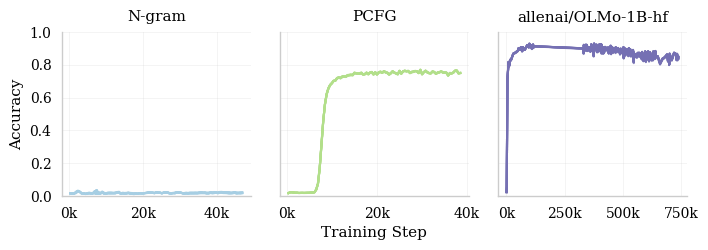

In [4]:

print("\nPlotting results...")

pcfg_steps = sorted(pcfg_history.keys())
pcfg_data = np.array([pcfg_history[s] for s in pcfg_steps])

ngram_steps = sorted(ngram_history.keys())
ngram_data = np.array([ngram_history[s] for s in ngram_steps]) if len(ngram_steps) > 0 else np.array([])

olmo_steps = sorted(olmo_history.keys())
olmo_data = np.array([olmo_history[s] for s in olmo_steps]) if len(olmo_steps) > 0 else np.array([])

print(f"PCFG: {len(pcfg_steps)} checkpoints")
print(f"Ngram: {len(ngram_steps)} checkpoints")
print(f"OLMo: {len(olmo_steps)} checkpoints")

if len(pcfg_steps) == 1:
    pcfg_data = pcfg_data.reshape(1, -1)
if len(ngram_steps) == 1:
    ngram_data = ngram_data.reshape(1, -1)
if len(olmo_steps) == 1:
    olmo_data = olmo_data.reshape(1, -1)

def set_black_labels(ax):
    ax.title.set_color("black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.tick_params(axis='x', colors='black')
    ax.tick_params(axis='y', colors='black')

fig, axes = plt.subplots(1, 3, figsize=(PAPER_WIDTH_IN, PAPER_HEIGHT_IN * 0.6), sharey=True)

if len(ngram_steps) > 0:
    for k in range(1, 11):
        axes[0].plot(ngram_steps, ngram_data[:, k-1], 
                     linewidth=1.5, alpha=0.6, color=COLOR_NGRAM)
    style_ax(axes[0], style="paper")
    axes[0].set_title('N-gram', fontsize=11, pad=8, color='black')
    axes[0].xaxis.set_major_formatter(get_step_formatter())
    set_black_labels(axes[0])
    axes[0].set_ylim(0.0, 1.0)
else:
    axes[0].text(0.5, 0.5, 'No data available', 
                ha='center', va='center', transform=axes[0].transAxes, fontsize=10)
    style_ax(axes[0], style="paper")
    axes[0].set_title('N-Gram', fontsize=11, pad=8, color='black')
    set_black_labels(axes[0])
    axes[0].set_ylim(0.0, 1.0)

for k in range(1, 11):
    axes[1].plot(pcfg_steps, pcfg_data[:, k-1], 
                 linewidth=1.5, alpha=0.6, color=COLOR_PCFG)
style_ax(axes[1], style="paper")
axes[1].set_title('PCFG', fontsize=11, pad=8, color='black')
axes[1].xaxis.set_major_formatter(get_step_formatter())
set_black_labels(axes[1])
axes[1].set_ylim(0.0, 1.0) 

if len(olmo_steps) > 0:
    for k in range(1, 11):
        axes[2].plot(olmo_steps, olmo_data[:, k-1], 
                     linewidth=1.5, alpha=0.6, color='#7570b3')
    style_ax(axes[2], style="paper")
    axes[2].set_title('allenai/OLMo-1B-hf', fontsize=11, pad=8, color='black')
    axes[2].xaxis.set_major_formatter(get_step_formatter())
    set_black_labels(axes[2])
    axes[2].set_ylim(0.0, 1.0)
else:
    axes[2].text(0.5, 0.5, 'No data available', 
                ha='center', va='center', transform=axes[2].transAxes, fontsize=10)
    style_ax(axes[2], style="paper")
    axes[2].set_title('allenai/OLMo-1B-hf', fontsize=11, pad=8, color='black')
    set_black_labels(axes[2])
    axes[2].set_ylim(0.0, 1.0)

axes[0].set_ylabel("Accuracy", color='black')
axes[1].set_ylabel(None)
axes[2].set_ylabel(None)

axes[0].set_xlabel(None)
axes[1].set_xlabel("Training Step", color='black')
axes[2].set_xlabel(None)

plt.tight_layout()
save_figure(fig, "induction_heads_curves.pdf")
plt.show()